# Lectura de datos en LTspice para Lib Razavi
Lectura y graficación de resultados de LTspice usando `spicelib`, `matplotlib`, `prettytable` y `si_prefix`.

Archivos usados en este notebook:
- `op` → `DC_Sweep_Razavi.log`
- `dc` → `DC_Sweep_Razavi.raw`

## 1. Imports
Se cargan una sola vez, se usan en todas las secciones siguientes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter, LogLocator, NullFormatter

from spicelib import RawRead
from spicelib.log.semi_dev_op_reader import opLogReader

from prettytable import PrettyTable
from si_prefix import si_format as num2eng

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# numpy renombro trapz -> trapezoid en versiones recientes; esto funciona con ambas
trapz = getattr(np, "trapezoid", None) or np.trapz


## 2. Funciones auxiliares
Formato de ejes con prefijos de ingeniería (n, u, k, M, G...), respetando tamaño/peso de fuente de los ticks en ambos ejes.

In [2]:
def format_loglog_axes(ax, y_unit="", labelsize=14, weight="normal"):
    """Aplica formato de prefijos de ingenieria a un par de ejes log-log
    (usar en graficas donde tanto X como Y estan en escala logaritmica,
    ej. espectros de ruido)."""
    ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 3, 5, 7), numticks=20))
    ax.yaxis.set_major_formatter(EngFormatter(unit=y_unit))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis="both", which="major", labelsize=labelsize)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight(weight)


def format_freq_axis(ax, labelsize=14, weight="normal"):
    """Aplica formato de prefijos de ingenieria al eje de frecuencia (X)
    y unifica tamano/peso de fuente en ambos ejes (X y Y). Usar en graficas
    semilogx, ej. Bode con ganancia en dB / fase en grados.

    IMPORTANTE en graficas con doble eje Y (twinx): llamar esta funcion
    DESPUES de graficar en ambos ejes (ax1 y ax2). twinx() comparte el
    mismo XAxis entre ambos ejes, y cualquier semilogx/set_xscale posterior
    (incluido el de ax2) resetea el formatter del eje X compartido a su
    default. Si se llama antes, el EngFormatter se pierde."""
    ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    ax.tick_params(axis="both", which="major", labelsize=labelsize)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight(weight)


## 3. Punto de operación (`.op`)

Lee `inv_op.log` y muestra el punto de operación de cada transistor en una tabla (filas = parámetros, columnas = transistores).

In [6]:
LOG_LTSPICE = r"DC_Sweep_Razavi.log"

op_data = opLogReader(LOG_LTSPICE)
mosfets = op_data["mosfet transistors"]

devices = list(mosfets.keys())
params  = ["Id", "Vgs", "Vds", "Vbs", "Vth", "Vdsat",
           "Gm", "Gds", "Gmb", "Cbd", "Cbs"]

table = PrettyTable()
table.field_names = ["Parámetro"] + devices

for p in params:
    row = [p]
    for dev in devices:
        row.append(num2eng(mosfets[dev][p]))
    table.add_row(row)

print(f"Punto de operación — {LOG_LTSPICE}\n")
print(table)


Punto de operación — DC_Sweep_Razavi.log

+-----------+---------+----------+
| Parámetro |  u1:M1  |  u2:M1   |
+-----------+---------+----------+
|     Id    |  75.7 µ | -37.8 µ  |
|    Vgs    | 900.0 m | -900.0 m |
|    Vds    | 900.0 m | -900.0 m |
|    Vbs    |   0.0   |   0.0    |
|    Vth    | 400.0 m | -400.0 m |
|   Vdsat   | 500.0 m | -500.0 m |
|     Gm    | 303.0 µ | 151.0 µ  |
|    Gds    |  6.9 µ  |  3.5 µ   |
|    Gmb    | 111.0 µ |  55.3 µ  |
|    Cbd    | 823.0 a | 823.0 a  |
|    Cbs    | 823.0 a | 823.0 a  |
+-----------+---------+----------+


## 4. DC Sweep
Curva de transferencia (VOUT), ganancia, corriente de drenador y transconductancia (gm) de U1.

In [8]:
RAW_LTSPICE_DC = r"DC_Sweep_Razavi.raw"

raw_dc = RawRead(RAW_LTSPICE_DC)

vgsn_dc   = raw_dc.get_trace("V(vgsn)").get_wave()
vdsn_dc  = raw_dc.get_trace("V(vdsn)").get_wave()
id_u1_dc = raw_dc.get_trace("Ix(u1:d)").get_wave()

# gds = dID/dVDS ; VDS(U1)=VOUT, pero VGS(U1)=VIN tambien varia en este barrido,
# asi que esta gds mezcla el efecto de VDS y VGS a lo largo de la curva de conmutacion.
gds_u1_dc = np.gradient(id_u1_dc, vdsn_dc)
rds_u1_dc = 1/gds_u1_dc


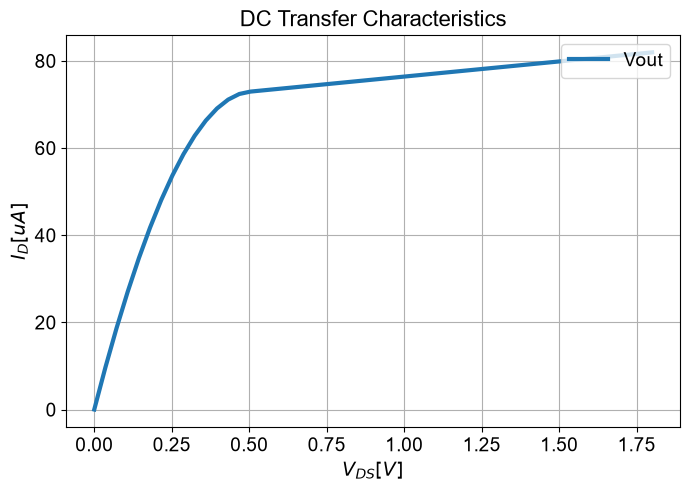

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(vdsn_dc, id_u1_dc*1e6, linewidth=3, label='Vout')
plt.legend(prop={"size": 14, 'weight': 'normal'}, loc="upper right")
plt.title('DC Transfer Characteristics', weight='normal', fontsize=16)
plt.xlabel(r'$V_{DS} [V]$', weight='normal', fontsize=14)
plt.ylabel(r'$I_{D} [uA]$', weight='normal', fontsize=14)
plt.xticks(weight='normal', fontsize=14)
plt.yticks(weight='normal', fontsize=14)
plt.grid()
plt.tight_layout()
plt.show()


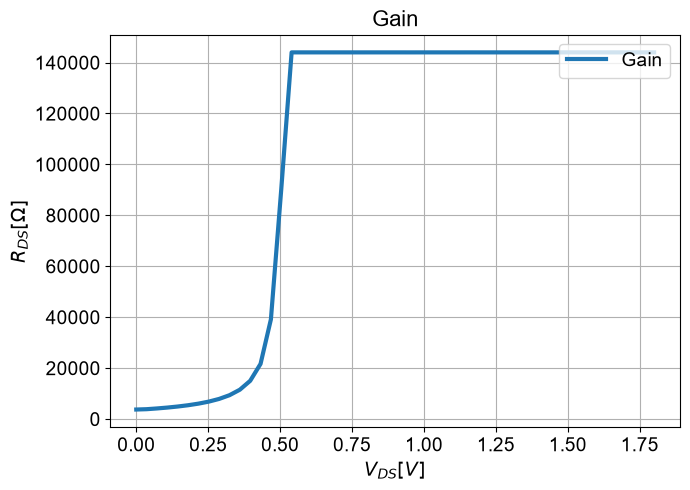

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(vdsn_dc, rds_u1_dc, linewidth=3, label='Gain')
plt.legend(prop={"size": 14, 'weight': 'normal'}, loc="upper right")
plt.title('Gain', weight='normal', fontsize=16)
plt.xlabel(r'$V_{DS} [V]$', weight='normal', fontsize=14)
plt.ylabel(r'$R_{DS} [Ω]$', weight='normal', fontsize=14)
plt.xticks(weight='normal', fontsize=14)
plt.yticks(weight='normal', fontsize=14)
plt.grid()
plt.tight_layout()
plt.show()
